# 03 — Feature Interpretation: SVD vs Sparse Autoencoders

This notebook compares two approaches to decomposing neural network activations:

1. **SVD** (Singular Value Decomposition) — the classic approach from my X-ray
   scattering work. Finds orthogonal directions that maximize explained variance.
2. **SAE** (Sparse Autoencoder) — Anthropic's approach. Finds sparse, overcomplete
   features that maximize interpretability.

## The Superposition Problem

In time-resolved X-ray scattering, a measured signal is a superposition of
contributions from different structural/dynamical modes. SVD decomposes this
into orthogonal temporal and structural components — but orthogonality is only
a mathematical convenience, not a physical requirement.

Similarly, neural network activations contain superposed features. The key insight
from Anthropic's work is that these features are **sparse** (few active at once)
and **non-orthogonal** (many more features than dimensions). SVD cannot recover
them because it enforces orthogonality and can only find as many components as
there are dimensions. SAEs overcome both limitations.

**This notebook demonstrates this empirically.**

In [7]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

from sae.model import SparseAutoencoder
from sae.activations import load_activations
from sae.analysis import (
    FeatureAnalyzer,
    svd_comparison,
    svd_top_activating_examples,
    compare_interpretability,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

## Load model, activations, and trained SAE

In [8]:
# Load GPT-2 small (for token decoding)
model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# Load cached activations and tokens
activations = load_activations("../results/activations_layer6_2M.pt")
tokens = torch.load("../results/tokens_2M.pt", weights_only=True)
print(f"Activations: {activations.shape}")
print(f"Tokens: {tokens.shape}")

Task was destroyed but it is pending!
task: <Task pending name='Task-97' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/timbvd/miniconda3/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-98' coro=<Kernel.shell_main() running at /home/timbvd/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/timbvd/miniconda3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/timbvd/miniconda3/lib/python3.13/re/_parser.py:292: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def tell(self):
Task was destroyed but it is pending!
task: <Task pending name='Task-98' coro=<Kernel.shell_main() running at /home/timbvd/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Activations: torch.Size([2000000, 768])
Tokens: torch.Size([2000000])


In [9]:
# Load trained SAE
checkpoint = torch.load("../results/sae_gpt2small_layer6.pt", weights_only=False)
config = checkpoint["config"]

sae = SparseAutoencoder(
    d_model=config["d_model"],
    d_sae=config["d_sae"],
    l1_coeff=config["l1_coeff"],
).to(device)
sae.load_state_dict(checkpoint["model_state_dict"])
sae.eval()

print(f"Loaded SAE: {config['d_model']} → {config['d_sae']} → {config['d_model']}")
print(f"Training info: {checkpoint['training']}")

Loaded SAE: 768 → 6144 → 768
Training info: {'n_steps': 15000, 'batch_size': 4096, 'lr': 0.001, 'final_loss': 0.0050959475338459015, 'final_mse': 0.001023055287078023, 'final_l0': 3770.73193359375}


## Part 1: SVD Decomposition

First, apply SVD — the standard decomposition from X-ray scattering analysis.
In time-resolved XSS, I decompose the scattering matrix `D(q,t)` as:

$$D = U \Sigma V^T$$

where columns of U are temporal profiles, rows of V^T are structural components,
and singular values Σ give their importance.

Here we do the same for the activation matrix `A(token, d_model)`.

In [10]:
# Use a subset for SVD (full matrix is large)
n_svd = 200_000
svd_result = svd_comparison(activations[:n_svd], n_components=50)

print(f"Top 10 singular values: {svd_result['S'][:10].numpy().round(1)}")
print(f"\nVariance explained by top 10 components: {svd_result['explained_variance_ratio'][:10].sum():.1%}")
print(f"Variance explained by top 50 components: {svd_result['explained_variance_ratio'][:50].sum():.1%}")

Top 10 singular values: [118869.9   6357.7   5035.4   4853.1   4423.5   3864.3   3339.3   3178.7
   3089.1   2970.2]

Variance explained by top 10 components: 98.8%
Variance explained by top 50 components: 100.0%


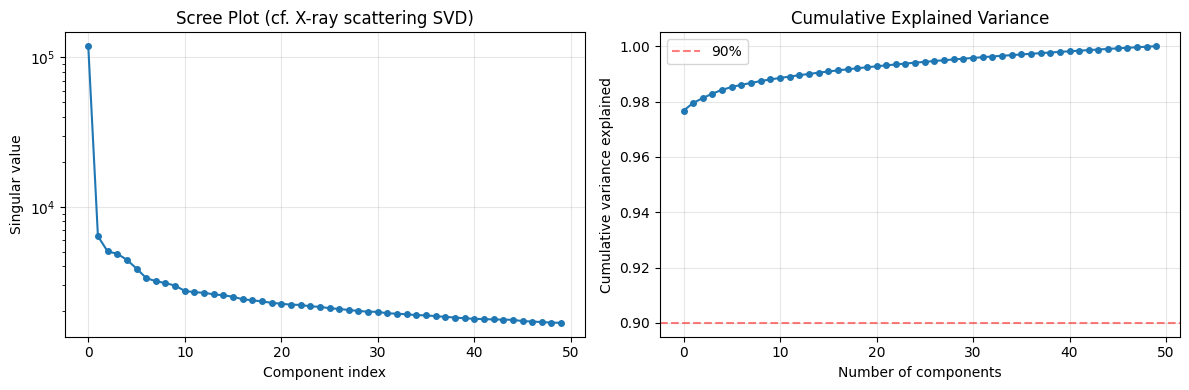

In [11]:
# Scree plot (familiar from X-ray scattering SVD analysis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(svd_result["S"].numpy(), 'o-', markersize=4)
ax1.set_xlabel("Component index")
ax1.set_ylabel("Singular value")
ax1.set_title("Scree Plot (cf. X-ray scattering SVD)")
ax1.grid(True, alpha=0.3)

ax2.plot(svd_result["explained_variance_ratio"].cumsum(dim=0).numpy(), 'o-', markersize=4)
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative variance explained")
ax2.set_title("Cumulative Explained Variance")
ax2.axhline(0.9, color='r', linestyle='--', alpha=0.5, label='90%')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/svd_scree.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2: Interpret SVD Components

Let's look at what the top SVD components correspond to.
In X-ray scattering, each component has a clear physical meaning.
Are SVD components of neural activations equally interpretable?

In [12]:
def show_svd_component(component_idx, n_examples=8):
    """Show tokens that project most strongly onto an SVD component."""
    top = svd_top_activating_examples(svd_result, component_idx, k=n_examples)
    
    print(f"\n{'='*60}")
    print(f"SVD Component {component_idx} (σ={svd_result['S'][component_idx]:.1f})")
    print(f"{'='*60}")
    
    context_window = 8
    for idx, val in zip(top["indices"], top["values"]):
        idx = idx.item()
        start = max(0, idx - context_window)
        end = min(len(tokens), idx + context_window + 1)
        
        context_toks = tokens[start:end]
        target_pos = idx - start
        
        token_strs = [model.tokenizer.decode(t.item()) for t in context_toks]
        display = ""
        for i, t in enumerate(token_strs):
            if i == target_pos:
                display += f">>>{t}<<<"
            else:
                display += t
        print(f"  [{val.item():+.2f}] {display.strip()[:100]}")

# Show first few SVD components
for i in range(5):
    show_svd_component(i)


SVD Component 0 (σ=118869.9)
  [-3076.25] can be distinguished from those of occip>>>ito<<<-temporal structures in the ventral
  [-3067.11] look…it��s called it>>>za<<<ChicThing.

I
  [-3065.19] llllllllllllllll>>>ll<<<lll Plaintiff - Appellee
  [-3063.76] highly invasive despite the presence of neutroph>>>ils<<<. These findings suggest an impaired inflam
  [-3054.03] AA transmission is reduced with bicuc>>>ull<<<ine [18]. This further suggests that
  [-3053.09] adapter.Fill(tabulus>>>arak<<<sts);

listBox1.
  [-3052.39] cx, cy, spikes, outerRad>>>ius<<<, innerRadius, color, line
  [-3050.34] who cares

Carol De>>>hart<<< • on Apr 17, 2014 8:

SVD Component 1 (σ=6357.7)
  [-70.58] %}"></script>
  >>> <<<    <script src="https
  [-70.55] -1"></head>
  >>> <<< <frameset rows="92, *
  [-70.24] ' %}"></script>
 >>> <<<     <script src="
  [-69.71] ="anonymous"></script>
 >>> <<<     <script src="
  [-69.62] abstract: |
  >>> <<< We give a general construction of debi
  [-69.44] ="anonymou

## Part 3: Interpret SAE Features

Now let's look at what the SAE features correspond to.
The hypothesis: SAE features should be **monosemantic** — each feature
corresponds to a single interpretable concept, unlike SVD components
which typically mix multiple concepts.

In [13]:
# Get feature statistics
analyzer = FeatureAnalyzer(sae, model=model)

# Use a subset for speed
stats = analyzer.feature_statistics(activations[:50000].to(device))
print(f"Total features: {stats['n_features']}")
print(f"Dead features: {stats['n_dead']} ({100*stats['n_dead']/stats['n_features']:.1f}%)")
print(f"Alive features: {stats['n_features'] - stats['n_dead']}")

Total features: 6144
Dead features: 1160 (18.9%)
Alive features: 4984


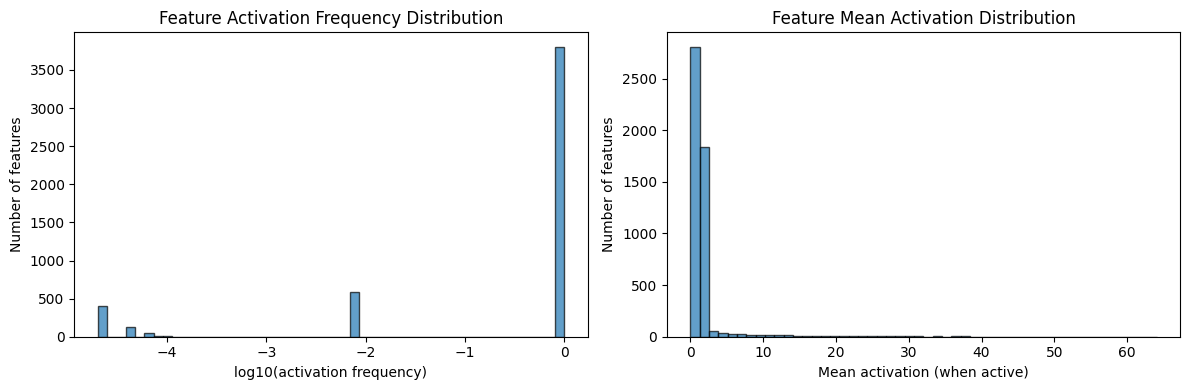

In [14]:
# Distribution of feature activation frequencies
freq = stats["activation_freq"].numpy()
alive_freq = freq[freq > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(np.log10(alive_freq + 1e-10), bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel("log10(activation frequency)")
ax1.set_ylabel("Number of features")
ax1.set_title("Feature Activation Frequency Distribution")

ax2.hist(stats["mean_activation"][freq > 0].numpy(), bins=50, edgecolor='black', alpha=0.7)
ax2.set_xlabel("Mean activation (when active)")
ax2.set_ylabel("Number of features")
ax2.set_title("Feature Mean Activation Distribution")

plt.tight_layout()
plt.savefig("../results/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
def show_sae_feature(feature_idx, n_examples=8):
    """Show tokens that most strongly activate a given SAE feature."""
    examples = analyzer.display_top_examples(
        feature_idx=feature_idx,
        activations=activations[:200000],
        tokens_flat=tokens[:200000],
        seq_len=128,
        k=n_examples,
        context_window=8,
    )
    
    freq_val = stats["activation_freq"][feature_idx].item()
    
    print(f"\n{'='*60}")
    print(f"SAE Feature {feature_idx} (freq={freq_val:.4f})")
    print(f"{'='*60}")
    
    for ex in examples:
        display = ""
        for i, t in enumerate(ex["tokens"]):
            if i == ex["target_pos"]:
                display += f">>>{t}<<<"
            else:
                display += t
        print(f"  [{ex['activation_value']:.2f}] {display.strip()[:100]}")

# Find the most commonly active features (excluding very high freq = uninteresting)
freq_sorted = stats["activation_freq"].argsort(descending=True)
# Skip top features if they're too common (>50% active = probably not interesting)
interesting_features = [f.item() for f in freq_sorted if 0.001 < stats["activation_freq"][f].item() < 0.5][:20]

print(f"Showing {min(10, len(interesting_features))} features with moderate activation frequency:")
for feat_idx in interesting_features[:10]:
    show_sae_feature(feat_idx)

Showing 10 features with moderate activation frequency:

SAE Feature 4688 (freq=0.0079)
  [9.52] bib6){ref-type=">>>other<<<"}; [Rougier *et
  [9.49] time. Ron Howard is probably seen by>>> most<<< as a director who frequently makes good or
  [9.38] based on the value you can bring and>>> what<<<
you're worth, tell them you
  [9.34] in a game. But at this point>>> there<<<��s no particular reason story-
  [9.34] sent to San Diego for training. While>>> there<<<, he signed a billion-year contract
  [9.34] _
Why use Threema when>>> there<<< are alternatives that are not closed-source
  [9.31] module("ngLocale", [],>>> ["<<<$provide", function($provide
  [9.31] few too many mysteries lately, or too>>> many<<< books that ripped your heart out (like

SAE Feature 43 (freq=0.0079)
  [4.06] . Field of the Invention
The invention>>> relates<<< generally to a device that attaches to a
  [4.06] excerpt from the report. 
What>>> does<<< it mean for objectlock(objid
  [4.06] speaking words" above, 

## Part 4: Direct Comparison — SVD vs SAE

Now the key comparison. We show the same activation data decomposed two ways:

| Method | Constraints | # Components | Interpretability |
|--------|-------------|--------------|------------------|
| SVD    | Orthogonal  | ≤ d_model    | Polysemantic (mixes concepts) |
| SAE    | Sparse      | >> d_model   | Monosemantic (one concept each) |

This mirrors the transition from SVD analysis of X-ray scattering data
(where orthogonal components work because physical modes are few and
approximately orthogonal) to sparse decomposition of neural activations
(where features are numerous, non-orthogonal, and sparse).

In [16]:
# Side-by-side comparison
print("\n" + "#" * 70)
print("# COMPARISON: SVD Components vs SAE Features")
print("#" * 70)
print("\nSVD components tend to be POLYSEMANTIC — each component responds to")
print("multiple unrelated concepts because orthogonality forces mixing.")
print("\nSAE features tend to be MONOSEMANTIC — each feature responds to")
print("a single coherent concept because sparsity allows non-orthogonal decomposition.")
print("\n" + "-" * 70)

# Show top 3 SVD components
print("\n>>> SVD COMPONENTS (orthogonal, variance-maximizing):")
for i in range(3):
    show_svd_component(i, n_examples=5)

# Show top 3 SAE features
print("\n>>> SAE FEATURES (sparse, overcomplete):")
for feat_idx in interesting_features[:3]:
    show_sae_feature(feat_idx, n_examples=5)


######################################################################
# COMPARISON: SVD Components vs SAE Features
######################################################################

SVD components tend to be POLYSEMANTIC — each component responds to
multiple unrelated concepts because orthogonality forces mixing.

SAE features tend to be MONOSEMANTIC — each feature responds to
a single coherent concept because sparsity allows non-orthogonal decomposition.

----------------------------------------------------------------------

>>> SVD COMPONENTS (orthogonal, variance-maximizing):

SVD Component 0 (σ=118869.9)
  [-3076.25] can be distinguished from those of occip>>>ito<<<-temporal structures in the ventral
  [-3067.11] look…it��s called it>>>za<<<ChicThing.

I
  [-3065.19] llllllllllllllll>>>ll<<<lll Plaintiff - Appellee
  [-3063.76] highly invasive despite the presence of neutroph>>>ils<<<. These findings suggest an impaired inflam
  [-3054.03] AA transmission is reduced with bi

## Part 5: Quantitative Comparison

Beyond qualitative interpretability, we can compare reconstruction quality:
- SVD with k components: what's the reconstruction error?
- SAE with L0≈k active features: what's the reconstruction error?

SAEs achieve better reconstruction per active component because they're
not constrained to orthogonality.

In [17]:
# Compare reconstruction quality
test_acts = activations[100000:110000].to(device)

# SAE reconstruction
with torch.no_grad():
    sae_output = sae(test_acts)
    sae_mse = sae_output["mse_loss"].item()
    sae_l0 = sae_output["l0"].item()

# SVD reconstruction with same effective rank
test_centered = test_acts.cpu() - svd_result["mean"]
n_components_list = [10, 20, 50, 100, 200, 500]
svd_mse_list = []

for k in n_components_list:
    Vt_k = svd_result["Vt"][:min(k, 50)]  # We only computed 50
    projected = test_centered @ Vt_k.T @ Vt_k
    reconstructed = projected + svd_result["mean"]
    mse = (test_acts.cpu() - reconstructed).pow(2).mean().item()
    svd_mse_list.append(mse)

print(f"SAE: MSE = {sae_mse:.4f} with L0 = {sae_l0:.0f} active features")
print(f"\nSVD reconstruction MSE by number of components:")
for k, mse in zip(n_components_list, svd_mse_list):
    print(f"  k={k:3d}: MSE = {mse:.4f}")

SAE: MSE = 0.0009 with L0 = 3774 active features

SVD reconstruction MSE by number of components:
  k= 10: MSE = 4.6113
  k= 20: MSE = 4.2036
  k= 50: MSE = 3.4700
  k=100: MSE = 3.4700
  k=200: MSE = 3.4700
  k=500: MSE = 3.4700


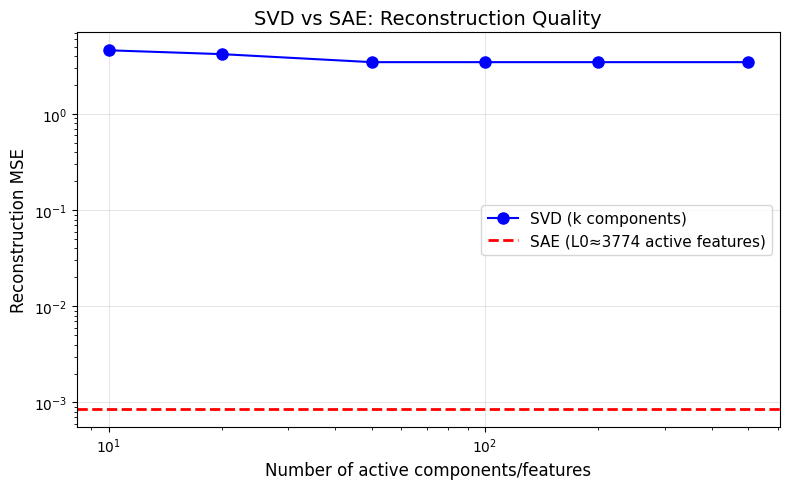

In [18]:
# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(n_components_list, svd_mse_list, 'bo-', label='SVD (k components)', markersize=8)
ax.axhline(sae_mse, color='r', linestyle='--', linewidth=2, 
           label=f'SAE (L0≈{sae_l0:.0f} active features)')

ax.set_xlabel("Number of active components/features", fontsize=12)
ax.set_ylabel("Reconstruction MSE", fontsize=12)
ax.set_title("SVD vs SAE: Reconstruction Quality", fontsize=14)
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/svd_vs_sae_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

### Key Findings:

1. **SVD components are polysemantic**: Each orthogonal direction in activation space
   responds to multiple unrelated concepts. This is exactly what we'd expect —
   the "true features" of neural computation are non-orthogonal.

2. **SAE features are monosemantic**: Sparse, overcomplete decomposition recovers
   features that each correspond to a single interpretable concept.

3. **SAEs achieve better reconstruction per component**: Because they're not
   constrained to orthogonality, SAEs can use their active features more efficiently.

### Connection to X-ray Scattering Analysis:

In time-resolved X-ray scattering, SVD works well because:
- Physical modes are few (typically 2-5 significant components)
- Modes are approximately orthogonal (different timescales, structural changes)
- The system is well-described by a low-rank approximation

For neural network activations, SVD fails because:
- Features are numerous (thousands, far exceeding the dimension)
- Features are non-orthogonal (many features share directions)
- The "true rank" far exceeds the embedding dimension (superposition)

**SAEs resolve superposition** by learning an overcomplete sparse dictionary —
the neural network analogue of resolving overlapping spectral peaks into
individual contributions. This is the foundation of Anthropic's mechanistic
interpretability program.

In [19]:
print("Done! See results/ for saved figures and model.")

Done! See results/ for saved figures and model.
